In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
final_clean_strained = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Distance": "first",
            "Total Variance": "first",
        }
    )
    .reset_index()
)

In [5]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [7]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = []
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = []
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Random Forest

In [8]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.173, R2 on test set: 0.192


# Feature Importance

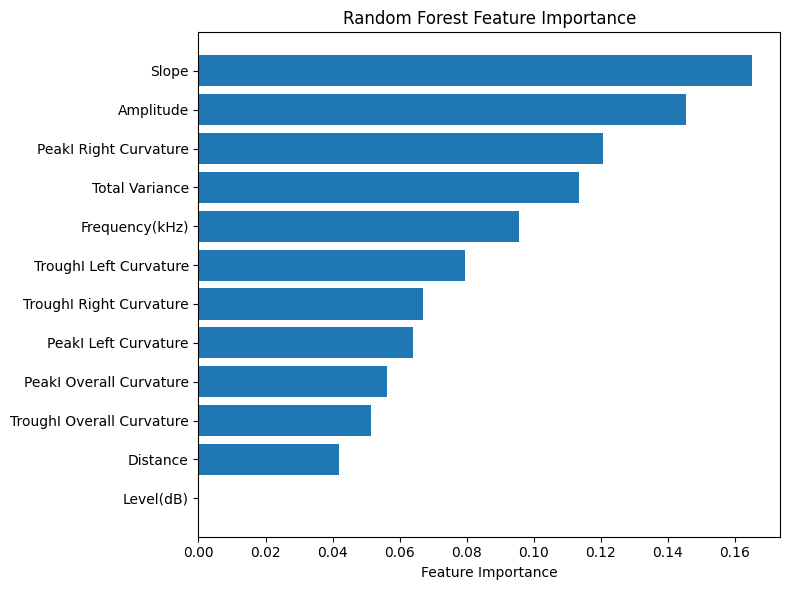

In [9]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
4              Frequency(kHz)         0.135137        0.049440
8       PeakI Right Curvature         0.026209        0.028676
11    TroughI Right Curvature         0.008810        0.010312
7     PeakI Overall Curvature         0.007533        0.012150
9      TroughI Left Curvature         0.005580        0.009166
3                   Level(dB)         0.000000        0.000000
6        PeakI Left Curvature        -0.002143        0.014424
2                    Distance        -0.004872        0.006369
10  TroughI Overall Curvature        -0.005497        0.009289
0                   Amplitude        -0.022414        0.023363
5              Total Variance        -0.030109        0.017426
1                       Slope        -0.038553        0.035407


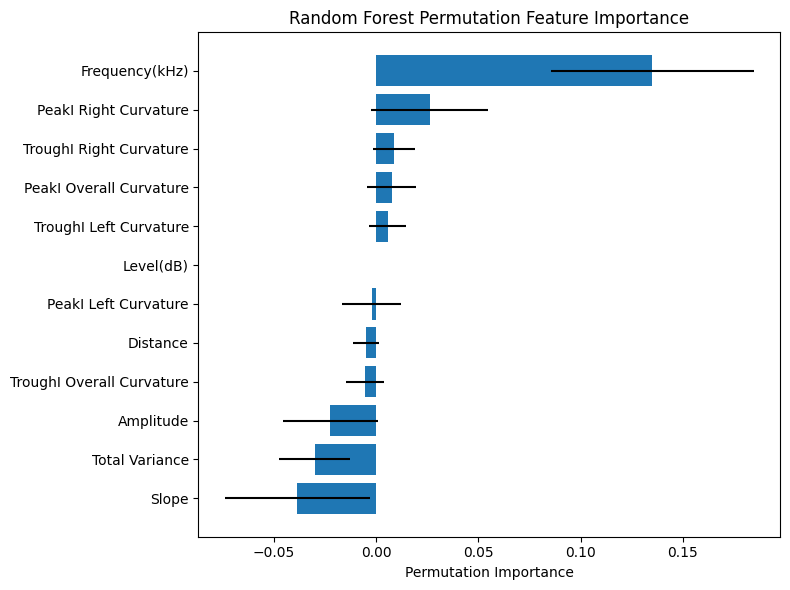

In [10]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'Distance'), Text(0, 2, 'TroughI Overall Curvature'), Text(0, 3, 'PeakI Overall Curvature'), Text(0, 4, 'TroughI Left Curvature'), Text(0, 5, 'PeakI Left Curvature'), Text(0, 6, 'TroughI Right Curvature'), Text(0, 7, 'Total Variance'), Text(0, 8, 'Frequency(kHz)'), Text(0, 9, 'PeakI Right Curvature'), Text(0, 10, 'Amplitude'), Text(0, 11, 'Slope')]


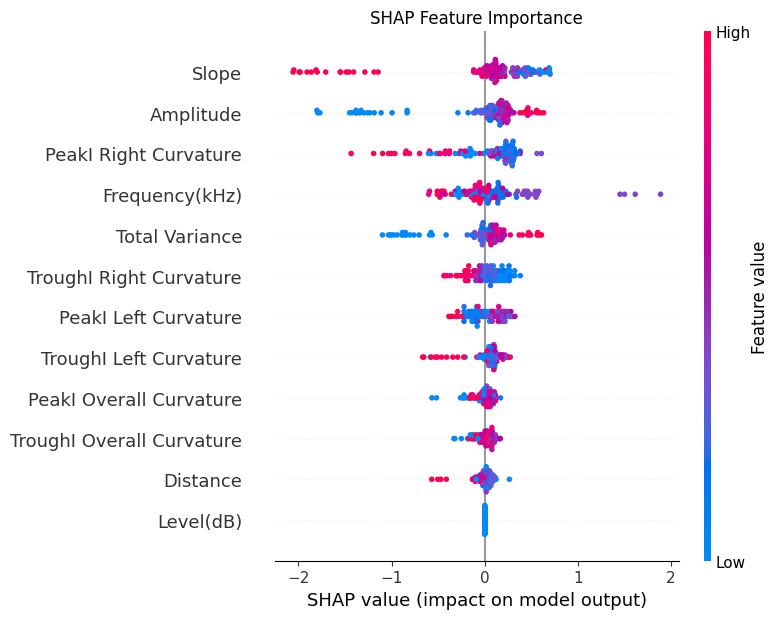

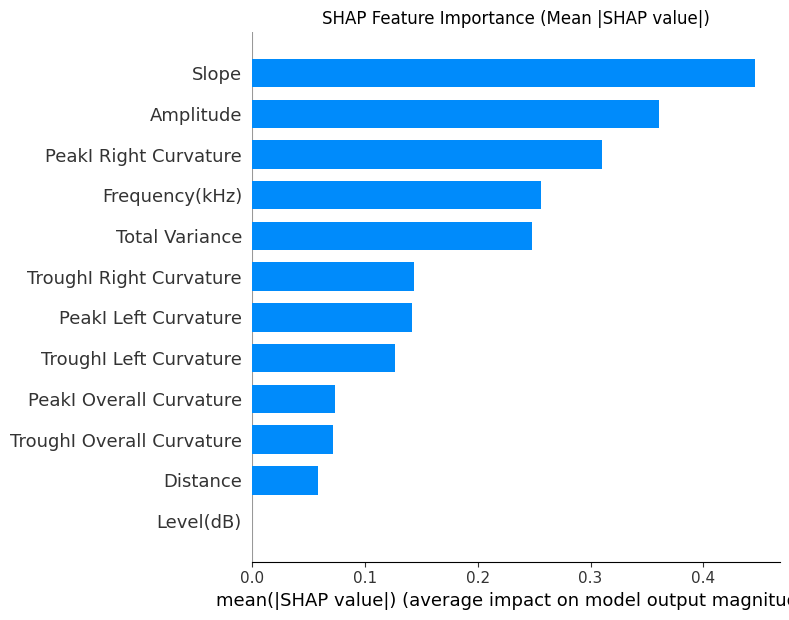

In [11]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [12]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [13]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

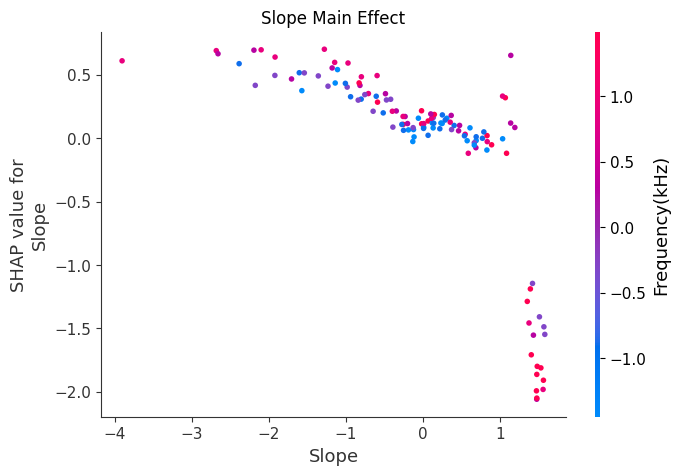

<Figure size 300x300 with 0 Axes>

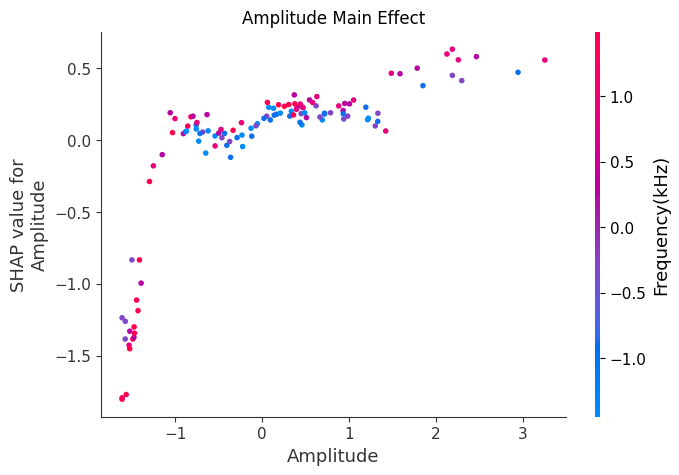

<Figure size 300x300 with 0 Axes>

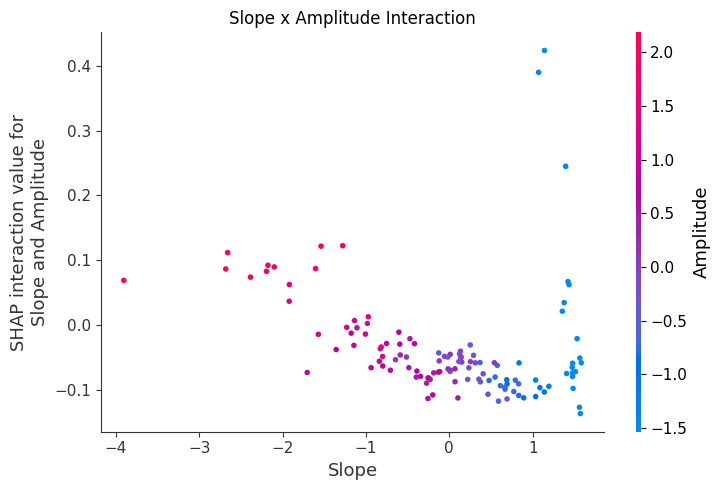

In [14]:
plot_shap_dependence(0, 1)

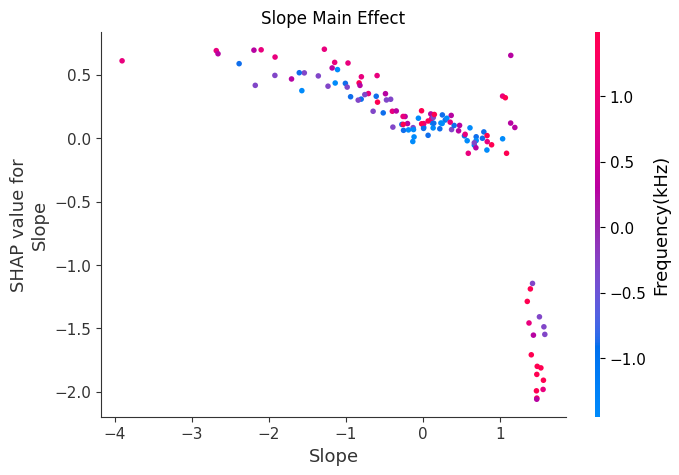

<Figure size 300x300 with 0 Axes>

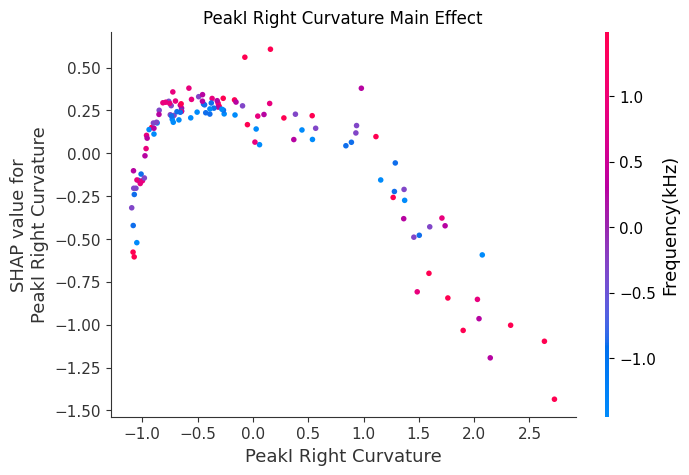

<Figure size 300x300 with 0 Axes>

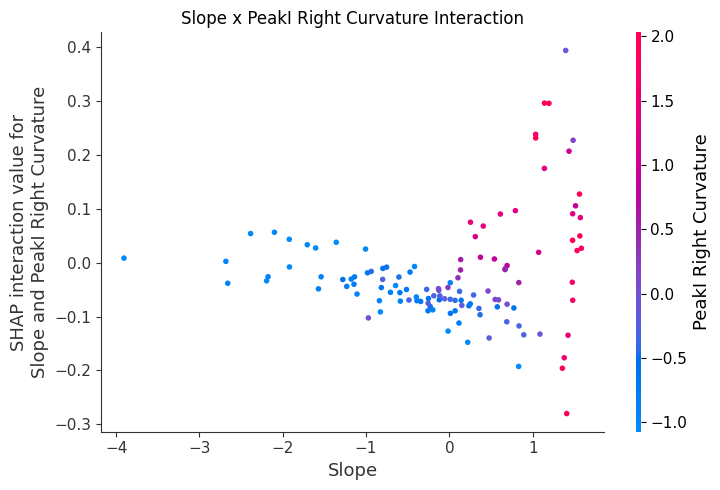

In [15]:
plot_shap_dependence(0, 2)

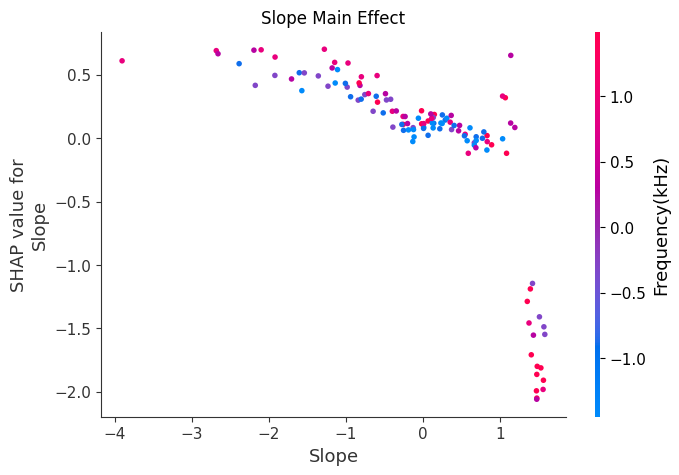

<Figure size 300x300 with 0 Axes>

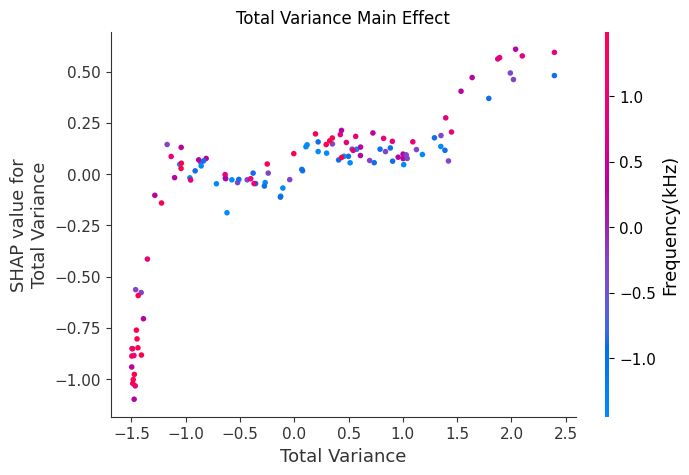

<Figure size 300x300 with 0 Axes>

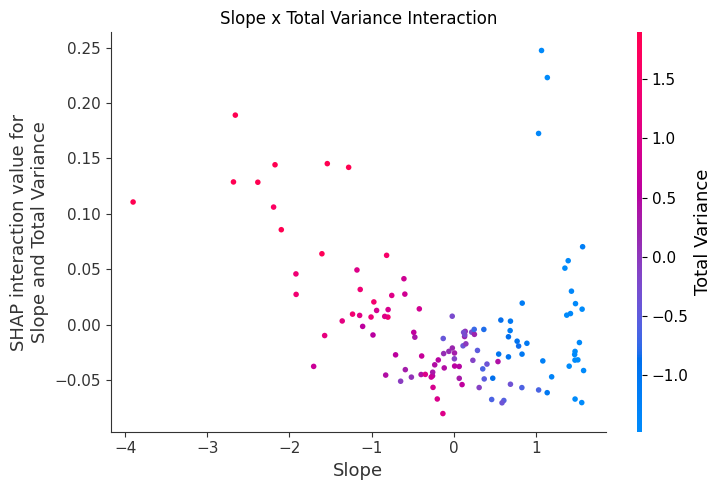

In [16]:
plot_shap_dependence(0, 3)

In [17]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [18]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 542 samples, R2: -0.027, RMSE: 1.996
20-25 dB, 870 samples, R2: 0.054, RMSE: 2.189
30-35 dB, 907 samples, R2: 0.019, RMSE: 2.351
40-45 dB, 802 samples, R2: 0.063, RMSE: 2.452
50-55 dB, 721 samples, R2: 0.181, RMSE: 2.625
60-65 dB, 719 samples, R2: 0.148, RMSE: 2.846
70-75 dB, 724 samples, R2: 0.313, RMSE: 3.067
80-85 dB, 616 samples, R2: 0.335, RMSE: 2.685
All data, 5901 samples, R2: 0.253, RMSE: 2.464


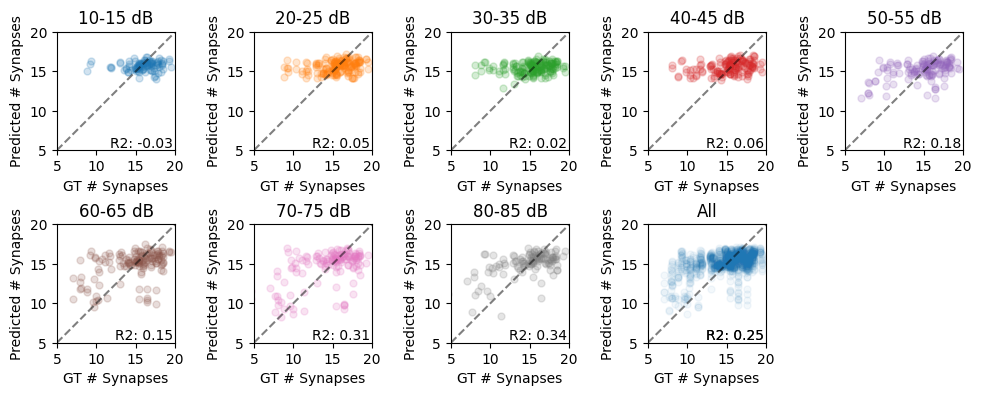

In [19]:
train_plot_result(final_clean_strained, best_rf_model)

Best RF score: 0.589, R2 on test set: 0.182
10-15 dB, 542 samples, R2: -0.035, RMSE: 2.004
20-25 dB, 870 samples, R2: 0.054, RMSE: 2.189
30-35 dB, 907 samples, R2: 0.023, RMSE: 2.347
40-45 dB, 802 samples, R2: 0.057, RMSE: 2.459
50-55 dB, 721 samples, R2: 0.197, RMSE: 2.599
60-65 dB, 719 samples, R2: 0.140, RMSE: 2.861
70-75 dB, 724 samples, R2: 0.303, RMSE: 3.090
80-85 dB, 616 samples, R2: 0.318, RMSE: 2.721
All data, 5901 samples, R2: 0.261, RMSE: 2.450


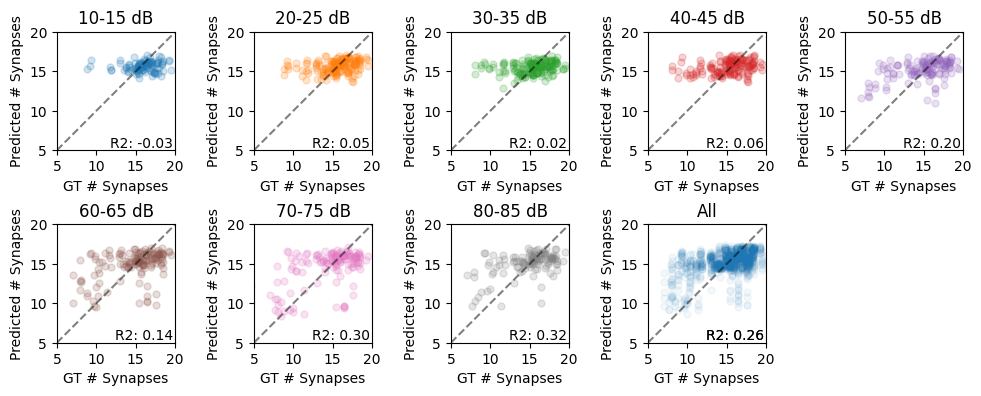

In [20]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

8.0Hz, 1043 samples, R2: -0.059, RMSE: 1.407
11.3Hz, 1009 samples, R2: -0.082, RMSE: 1.142
16.0Hz, 979 samples, R2: 0.017, RMSE: 1.454
22.6Hz, 953 samples, R2: 0.216, RMSE: 2.957
32.0Hz, 947 samples, R2: 0.211, RMSE: 3.309
45.2Hz, 970 samples, R2: 0.141, RMSE: 3.354
All data, 5901 samples, R2: 0.261, RMSE: 2.450


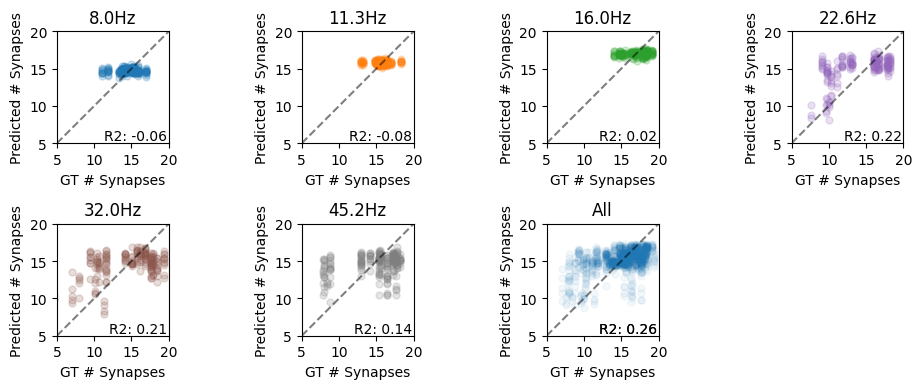

In [21]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()


train_plot_result_frequency(final_clean_strained, rf_pipeline)

8.0Hz, 1043 samples, R2: -0.033, RMSE: 1.349
11.3Hz, 1009 samples, R2: 0.001, RMSE: 1.132
16.0Hz, 979 samples, R2: 0.067, RMSE: 1.416
22.6Hz, 953 samples, R2: 0.323, RMSE: 2.856
32.0Hz, 947 samples, R2: 0.325, RMSE: 3.399
45.2Hz, 970 samples, R2: 0.375, RMSE: 3.490
All data, 5901 samples, R2: 0.409, RMSE: 2.532


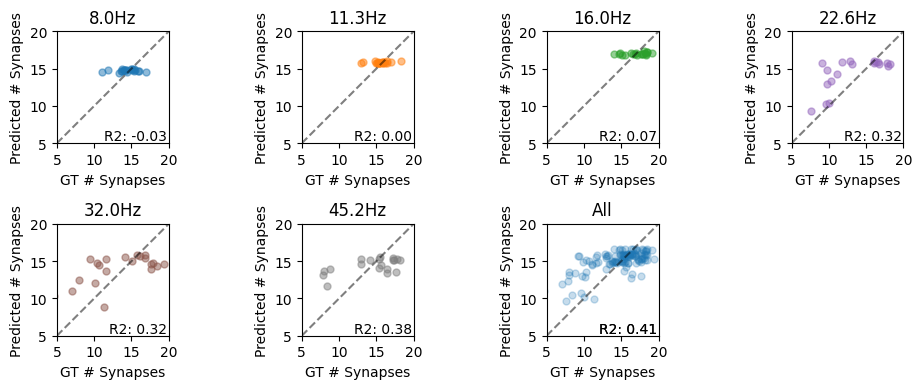

In [22]:
from sklearn.metrics import r2_score


def train_plot_result_frequency_grouped(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            test = data[data.DataGroup == "Test"].copy()
            test["preds"] = rf_pipeline.predict(X_test1)
            grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                {"SynapsesPerIHC": "mean", "preds": "mean"}
            )
            r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
            rmse = np.sqrt(
                np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
            )
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                grouped_preds["SynapsesPerIHC"],
                grouped_preds["preds"],
                title=f"{frq}Hz",
                color=color_palette(i),
                alpha=0.5,
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    test = df[df.DataGroup == "Test"].copy()
    test["preds"] = rf_pipeline.predict(X_test)
    grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
        {"SynapsesPerIHC": "mean", "preds": "mean"}
    )
    r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
    rmse = np.sqrt(
        np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
    )
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        grouped_preds["SynapsesPerIHC"],
        grouped_preds["preds"],
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()


train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

In [23]:
minmax_features = ["Noise", "Time (hrs)"]
X_train_noise, X_test_noise, y_train_noise, y_test_noise, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search_noise = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search_noise.fit(X_train_noise, y_train_noise)
print(f"Best RF params: {rf_search_noise.best_params_}")
r2 = rf_search_noise.score(X_test_noise, y_test_noise)
print(f"Best RF score: {rf_search_noise.best_score_:.3f}, R2 on test set: {r2:.3f}")
noise_rf_model = rf_search_noise.best_estimator_

Best RF params: {'rf__n_estimators': 25, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 40}
Best RF score: 0.451, R2 on test set: 0.470


In [24]:
noise_feature_importance = noise_rf_model.named_steps["rf"].feature_importances_
noise_feature_names = noise_rf_model.feature_names_in_

noise_importance_df = pd.DataFrame(
    {"Feature": noise_feature_names, "Importance w/ Noise": noise_feature_importance}
).sort_values("Importance w/ Noise", ascending=False)

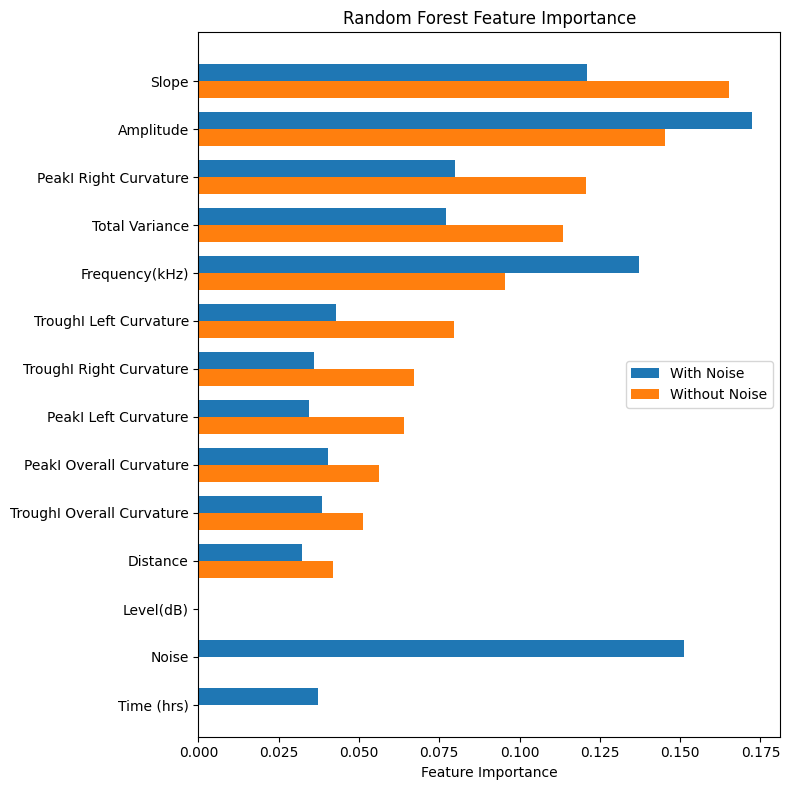

In [25]:
joined_importance_df = pd.concat(
    [importance_df.set_index("Feature"), noise_importance_df.set_index("Feature")],
    axis=1,
)
idx = np.arange(len(joined_importance_df["Importance"]))
bar_height = 0.35

plt.figure(figsize=(8, 8))
plt.barh(
    idx - bar_height / 2,
    joined_importance_df["Importance w/ Noise"],
    label="With Noise",
    height=bar_height,
)
plt.barh(
    idx + bar_height / 2,
    joined_importance_df["Importance"],
    label="Without Noise",
    height=bar_height,
)
plt.yticks(idx, joined_importance_df.index.values)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.legend()
plt.show()

In [26]:
perm_importance_noise = permutation_importance(
    noise_rf_model,
    X_test_noise,
    y_test_noise,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
noise_perm_importance_df = pd.DataFrame(
    {
        "Feature": noise_feature_names,
        "Importance_Mean_n": perm_importance_noise.importances_mean,
        "Importance_Std_n": perm_importance_noise.importances_std,
    }
).sort_values("Importance_Mean_n", ascending=False)

print("\nPermutation Importance Rankings:")
print(noise_perm_importance_df)


Permutation Importance Rankings:
                      Feature  Importance_Mean_n  Importance_Std_n
12                      Noise           0.327009          0.069533
4              Frequency(kHz)           0.257058          0.064566
0                   Amplitude           0.053565          0.033044
8       PeakI Right Curvature           0.039396          0.018648
13                 Time (hrs)           0.022829          0.013587
11    TroughI Right Curvature           0.012952          0.007933
2                    Distance           0.009130          0.005442
1                       Slope           0.006784          0.027094
3                   Level(dB)           0.000000          0.000000
9      TroughI Left Curvature          -0.001072          0.007945
10  TroughI Overall Curvature          -0.002267          0.006587
7     PeakI Overall Curvature          -0.008526          0.009344
6        PeakI Left Curvature          -0.009980          0.005240
5              Total Varianc

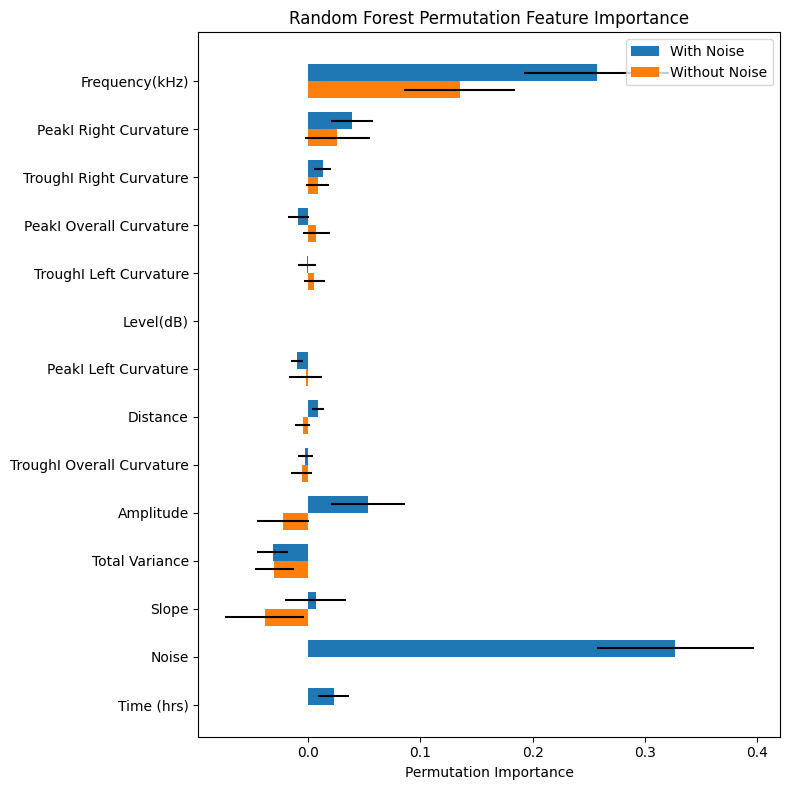

In [27]:
joined_perm_importance_df = pd.concat(
    [
        perm_importance_df.set_index("Feature"),
        noise_perm_importance_df.set_index("Feature"),
    ],
    axis=1,
)
idx = np.arange(len(joined_perm_importance_df["Importance_Mean_n"]))
bar_height = 0.35
plt.figure(figsize=(8, 8))
plt.barh(
    idx - bar_height / 2,
    joined_perm_importance_df["Importance_Mean_n"],
    xerr=joined_perm_importance_df["Importance_Std_n"],
    label="With Noise",
    height=bar_height,
)
plt.barh(
    idx + bar_height / 2,
    joined_perm_importance_df["Importance_Mean"],
    xerr=joined_perm_importance_df["Importance_Std"],
    label="Without Noise",
    height=bar_height,
)
plt.yticks(idx, joined_perm_importance_df.index.values)
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.legend()
plt.show()

In [28]:
data = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
data = split_by_mouse(data)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
data["Noise_cat"] = [0 if x else 1 for x in (data["Noise"] == 0)]
# minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)
X = data[num_features + cat_features + log_features + minmax_features]
y = data["Noise_cat"]

X_train, X_test, y_train, y_test = (
    X[data.DataGroup != "Test"],
    X[data.DataGroup == "Test"],
    y[data.DataGroup != "Test"],
    y[data.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
        # ("minmax_scale", MinMaxScaler(), minmax_features),
    ]
)

In [29]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 15, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.673, R2 on test set: 0.633


In [30]:
X = data[num_features + cat_features + log_features]
rf_pipeline.fit(X_train, y_train)
data["noise_preds"] = rf_pipeline.predict(X)

In [31]:
X = final_clean_strained[num_features + cat_features + log_features]
rf_pipeline.fit(X_train, y_train)
final_clean_strained["noise_preds"] = rf_pipeline.predict(X)

In [32]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["noise_preds", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [33]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.217, R2 on test set: 0.240


10-15 dB, 542 samples, R2: -0.046, RMSE: 2.014
20-25 dB, 870 samples, R2: 0.118, RMSE: 2.113
30-35 dB, 907 samples, R2: 0.100, RMSE: 2.252
40-45 dB, 802 samples, R2: 0.102, RMSE: 2.400
50-55 dB, 721 samples, R2: 0.295, RMSE: 2.436
60-65 dB, 719 samples, R2: 0.220, RMSE: 2.723
70-75 dB, 724 samples, R2: 0.340, RMSE: 3.007
80-85 dB, 616 samples, R2: 0.394, RMSE: 2.564
All data, 5901 samples, R2: 0.310, RMSE: 2.368


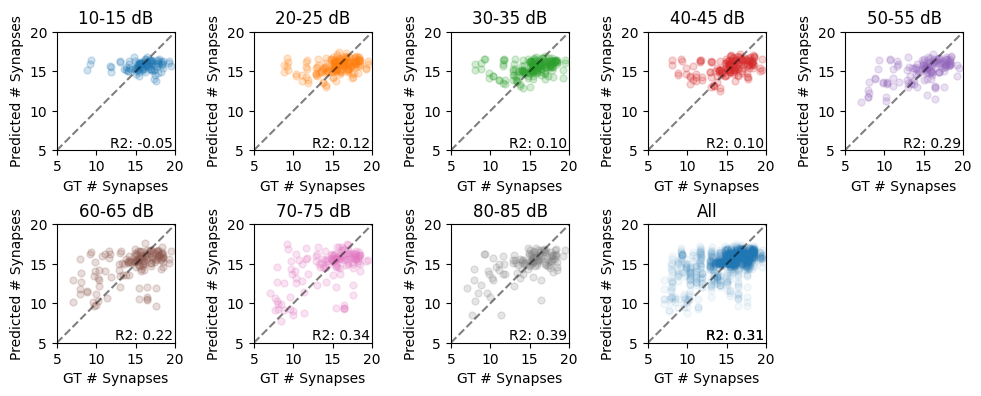

In [34]:
train_plot_result(final_clean_strained, best_rf_model)

8.0Hz, 1043 samples, R2: 0.505, RMSE: 0.934
11.3Hz, 1009 samples, R2: 0.220, RMSE: 1.000
16.0Hz, 979 samples, R2: 0.089, RMSE: 1.400
22.6Hz, 953 samples, R2: 0.347, RMSE: 2.805
32.0Hz, 947 samples, R2: 0.354, RMSE: 3.324
45.2Hz, 970 samples, R2: 0.418, RMSE: 3.369
All data, 5901 samples, R2: 0.466, RMSE: 2.408


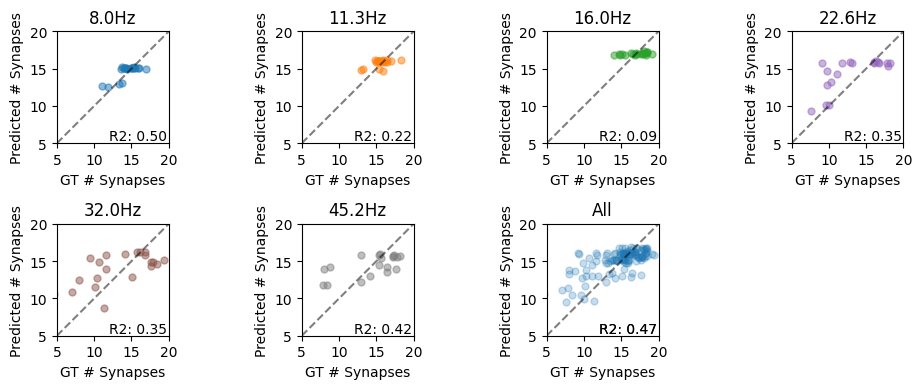

In [35]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)